# SHAP Explainability Notebook

Global and local feature importance from a trained model.joblib

In [1]:

import json
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


In [2]:

MODEL_PATH = "../model.joblib"
TRAIN_CSV_PATH = "../data/raw/application_train.csv"
ID_COL = "SK_ID_CURR"
CLIENT_ID = 100002  # set to None if no local explanation
BACKGROUND_SIZE = 1000
OUT_PREFIX = "credit"
ADD_RATIOS = True


## Add new features

In [3]:

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if {"AMT_INCOME_TOTAL", "AMT_CREDIT"}.issubset(df.columns):
        df["RATIO_CREDIT_INCOME"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    if {"AMT_ANNUITY", "AMT_CREDIT"}.issubset(df.columns):
        df["RATIO_ANNUITY_CREDIT"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]
    if {"DAYS_EMPLOYED", "DAYS_BIRTH"}.issubset(df.columns):
        df["RATIO_EMPLOYED_BIRTH"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]
    return df


## Load trained best model

In [4]:

pipe = joblib.load(MODEL_PATH)

df = pd.read_csv(TRAIN_CSV_PATH)
if "TARGET" in df.columns:
    df = df.drop(columns=["TARGET"])

if ADD_RATIOS:
    df = add_engineered_features(df)

pre = pipe.named_steps["pre"]
model = pipe.named_steps["model"]

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = None

print("Model loaded")
print("Data shape:", df.shape)


Model loaded
Data shape: (99999, 124)


## SHAP global importance / global summary(beeswarm)

In [5]:

def ensure_dense(X):
    try:
        import scipy.sparse as sp
        if sp.issparse(X):
            return X.toarray()
    except Exception:
        pass
    return np.asarray(X)

bg = df.sample(min(BACKGROUND_SIZE, len(df)), random_state=42)
X_bg_trans = ensure_dense(pre.transform(bg))

explainer = shap.TreeExplainer(model)
shap_bg = explainer.shap_values(X_bg_trans)
base_value = explainer.expected_value

print("SHAP global computed")


SHAP global computed


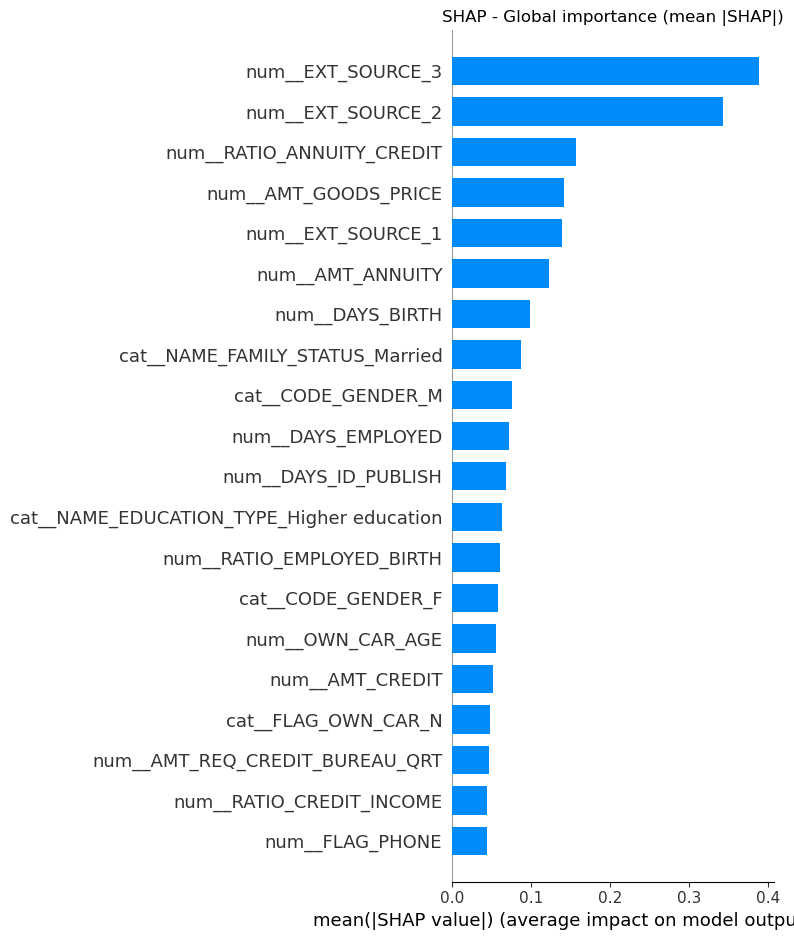

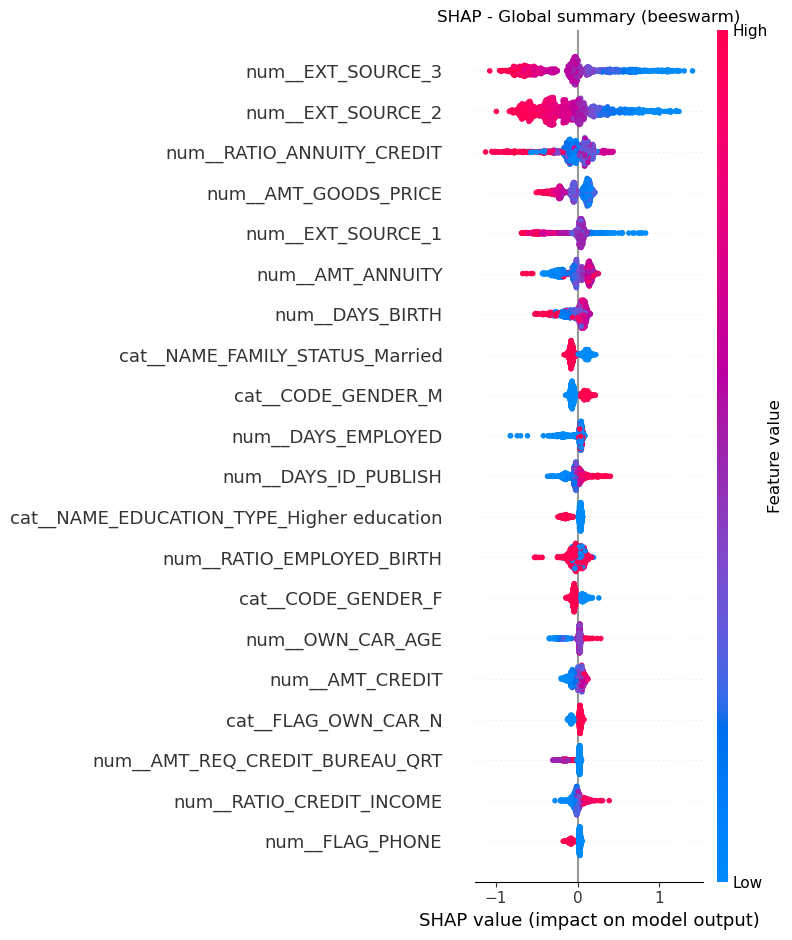

,feature,mean_abs_shap
30,num__EXT_SOURCE_3,0.388480
29,num__EXT_SOURCE_2,0.342989
106,num__RATIO_ANNUITY_CREDIT,0.157097
5,num__AMT_GOODS_PRICE,0.142253
28,num__EXT_SOURCE_1,0.139038
4,num__AMT_ANNUITY,0.122396
7,num__DAYS_BIRTH,0.098304
139,cat__NAME_FAMILY_STATUS_Married,0.087429
111,cat__CODE_GENDER_M,0.076243
8,num__DAYS_EMPLOYED,0.071964


In [6]:

plt.figure()
shap.summary_plot(
    shap_bg,
    features=X_bg_trans,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP - Global importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_global_bar.png", dpi=200)
plt.show()

plt.figure()
shap.summary_plot(
    shap_bg,
    features=X_bg_trans,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP - Global summary (beeswarm)")
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_global_beeswarm.png", dpi=200)
plt.show()

n_features = shap_bg.shape[1]
names = list(feature_names) if feature_names is not None else [f"f{i}" for i in range(n_features)]

global_df = (
    pd.DataFrame({"feature": names, "mean_abs_shap": np.abs(shap_bg).mean(axis=0)})
    .sort_values("mean_abs_shap", ascending=False)
)
global_df.to_csv(f"{OUT_PREFIX}_global_importance.csv", index=False)
global_df.head(15)


## Local SHAP waterfall for choosen CLIENT_ID

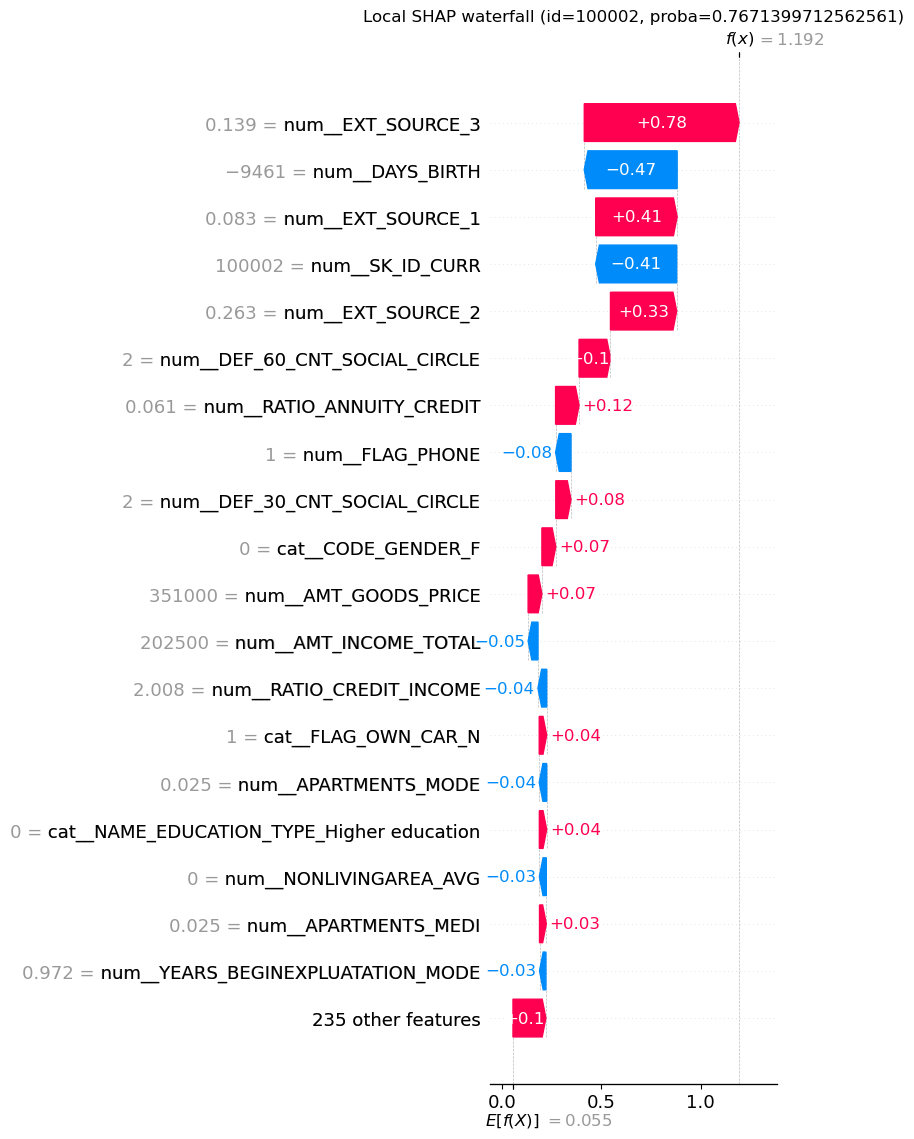

In [7]:

if CLIENT_ID is not None:
    rows = df[df[ID_COL] == CLIENT_ID]
    if rows.empty:
        raise ValueError("Client not found")

    x_one = rows.iloc[[0]]
    proba = float(pipe.predict_proba(x_one)[0, 1]) if hasattr(pipe, "predict_proba") else None

    X_one_trans = ensure_dense(pre.transform(x_one))
    shap_one = explainer.shap_values(X_one_trans)
    shap_row = shap_one[0]
    x_row = X_one_trans[0]

    exp = shap.Explanation(
        values=shap_row,
        base_values=base_value,
        data=x_row,
        feature_names=feature_names
    )

    plt.figure()
    shap.plots.waterfall(exp, show=False, max_display=20)
    plt.title(f"Local SHAP waterfall (id={CLIENT_ID}, proba={proba})")
    plt.tight_layout()
    plt.savefig(f"{OUT_PREFIX}_local_waterfall_{CLIENT_ID}.png", dpi=200)
    plt.show()

    local_df = (
        pd.DataFrame({
            "feature": names,
            "value_transformed": x_row,
            "shap": shap_row,
            "abs_shap": np.abs(shap_row)
        })
        .sort_values("abs_shap", ascending=False)
    )
    local_df.to_csv(f"{OUT_PREFIX}_local_contrib_{CLIENT_ID}.csv", index=False)

    summary = {
        "client_id": CLIENT_ID,
        "proba": proba,
        "top10": local_df.head(10)[["feature", "shap", "abs_shap"]].to_dict(orient="records")
    }
    with open(f"{OUT_PREFIX}_local_summary_{CLIENT_ID}.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    local_df.head(15)
else:
    print("No local explanation requested")
